# Echo Epoch Metric Aggregation

Aggregate the per-video SAMWISE Echo epoch scoring outputs into summaries by class, view, and dataset.

This notebook expects the outputs produced by `scripts/eval_echo_epoch_p2flow_metrics.py` and can be pointed at either the `valid` or `external` split.

In [106]:
from pathlib import Path
import json
import math
from PIL import Image

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)


In [107]:
EXP_DIR = Path('output/echo_refvos_train')
EPOCH = 3
# SPLIT = 'valid'
SPLIT = 'test'
# SPLIT = 'external'
METHOD_NAME = 'SAMWISE'
PARAMS_M = '-'
FLOPS_G = '-'
DATASET_ORDER = (
    ['CardiacNet', 'HMC_QU', 'Private']
    if SPLIT == 'external'
    else ['Camus', 'CardiacUDA', 'EchoCP', 'SegRWMA'] #, 'EchoNet-Pediatric']
)


def resolve_eval_dir(exp_dir: Path, epoch: int, split: str) -> tuple[Path, Path]:
    candidates: list[tuple[Path, Path]] = []
    if split in {'external', 'test'}:
        split_exp_dirs = [
            exp_dir.parent / f'{exp_dir.name}_{split}_ep{epoch}',
            exp_dir.parent / f'{exp_dir.name}_{split}_epoch{epoch:02d}',
        ]
        for split_exp_dir in split_exp_dirs:
            candidates.append((split_exp_dir, split_exp_dir / 'eval_echo' / split))
    candidates.append((exp_dir, exp_dir / f'valid_epoch{epoch:02d}' / 'eval_echo' / split))
    candidates.append((exp_dir, exp_dir / 'eval_echo' / split))

    for candidate_exp_dir, candidate_eval_dir in candidates:
        if candidate_eval_dir.exists():
            return candidate_exp_dir, candidate_eval_dir

    return candidates[0]


EXP_DIR, VALID_DIR = resolve_eval_dir(EXP_DIR, EPOCH, SPLIT)
EPOCH_DIR = VALID_DIR.parent.parent if VALID_DIR.parent.name == 'eval_echo' else EXP_DIR / f'valid_epoch{EPOCH:02d}'
CSV_PATH = VALID_DIR / 'metrics_p2flow_per_video.csv'
JSON_PATH = VALID_DIR / 'metrics_p2flow_per_video.json'

print('EXP_DIR:', EXP_DIR.resolve())
print('EPOCH_DIR:', EPOCH_DIR.resolve())
print('VALID_DIR:', VALID_DIR.resolve())
print('SPLIT:', SPLIT)
print('CSV_PATH exists:', CSV_PATH.exists())
print('JSON_PATH exists:', JSON_PATH.exists())

EXP_DIR: /home/ultrai/UltrAi/moein/SAMWISE/output/echo_refvos_train_test_epoch03
EPOCH_DIR: /home/ultrai/UltrAi/moein/SAMWISE/output/echo_refvos_train_test_epoch03
VALID_DIR: /home/ultrai/UltrAi/moein/SAMWISE/output/echo_refvos_train_test_epoch03/eval_echo/test
SPLIT: test
CSV_PATH exists: True
JSON_PATH exists: True


In [108]:
def resolve_metric_paths(csv_path: Path, json_path: Path) -> tuple[Path, Path]:
    candidates = [(csv_path, json_path)]
    split = globals().get('SPLIT', 'valid')
    exp_dir = globals().get('EXP_DIR', Path('output/echo_refvos_train'))
    epoch = int(globals().get('EPOCH', 0))
    split_dir = exp_dir / f'valid_epoch{epoch:02d}' / 'eval_echo' / split
    candidates.append((split_dir / 'metrics_p2flow_per_video.csv', split_dir / 'metrics_p2flow_per_video.json'))
    split_dir = exp_dir / 'eval_echo' / split
    candidates.append((split_dir / 'metrics_p2flow_per_video.csv', split_dir / 'metrics_p2flow_per_video.json'))
    if split in {'test', 'external'}:
        split_exp_dirs = [
            exp_dir.parent / f'{exp_dir.name}_{split}_ep{epoch}',
            exp_dir.parent / f'{exp_dir.name}_{split}_epoch{epoch:02d}',
        ]
        for split_exp_dir in split_exp_dirs:
            split_dir = split_exp_dir / 'eval_echo' / split
            candidates.append((split_dir / 'metrics_p2flow_per_video.csv', split_dir / 'metrics_p2flow_per_video.json'))

    seen = set()
    for candidate_csv, candidate_json in candidates:
        key = (str(candidate_csv), str(candidate_json))
        if key in seen:
            continue
        seen.add(key)
        if candidate_csv.exists() or candidate_json.exists():
            return candidate_csv, candidate_json

    return csv_path, json_path


def load_metric_rows(csv_path: Path, json_path: Path) -> pd.DataFrame:
    csv_path, json_path = resolve_metric_paths(csv_path, json_path)
    print('Resolved CSV_PATH:', csv_path)
    print('Resolved JSON_PATH:', json_path)
    if csv_path.exists():
        df = pd.read_csv(
            csv_path,
            dtype={
                'video_id': str,
                'dataset': str,
                'view': str,
                'clip_id': str,
                'exp_id': str,
                'obj_id': str,
                'class_name': str,
                'frame': str,
            },
        )
    elif json_path.exists():
        payload = json.loads(json_path.read_text())
        rows = []
        for video_id, video_payload in payload.get('videos', {}).items():
            rows.extend(video_payload.get('records', []))
        df = pd.DataFrame(rows)
    else:
        raise FileNotFoundError(f'Neither CSV nor JSON exists: {csv_path} | {json_path}')

    if df.empty:
        raise ValueError('Loaded metric table is empty.')

    for col in ['video_id', 'dataset', 'view', 'clip_id', 'exp_id', 'obj_id', 'class_name', 'frame']:
        if col in df.columns:
            df[col] = df[col].astype(str)

    for col in ['dice', 'iou', 'hd95']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


df = load_metric_rows(CSV_PATH, JSON_PATH)
print('Rows:', len(df))
print('Videos:', df['video_id'].nunique())
print('Datasets:', sorted(df['dataset'].unique().tolist()))
print('Views:', sorted(df['view'].unique().tolist()))
print('Classes:', sorted(df['class_name'].unique().tolist()))
display(df.head())

Resolved CSV_PATH: output/echo_refvos_train_test_epoch03/eval_echo/test/metrics_p2flow_per_video.csv
Resolved JSON_PATH: output/echo_refvos_train_test_epoch03/eval_echo/test/metrics_p2flow_per_video.json
Rows: 9123
Videos: 978
Datasets: ['Camus', 'CardiacUDA', 'EchoCP', 'EchoNet-Pediatric', 'SegRWMA']
Views: ['2CH', '3CH', '4CH', 'PSAX']
Classes: ['LA', 'LV', 'MYO', 'RA', 'RV']


,video_id,dataset,view,clip_id,exp_id,obj_id,class_name,frame,dice,iou,hd95
0,Camus__2CH__patient0004,Camus,2CH,patient0004,0,1,LV,000,0.949872,0.904530,5.000000
1,Camus__2CH__patient0004,Camus,2CH,patient0004,0,1,LV,001,0.961641,0.926116,4.000000
2,Camus__2CH__patient0004,Camus,2CH,patient0004,0,1,LV,002,0.955556,0.914894,4.242641
3,Camus__2CH__patient0004,Camus,2CH,patient0004,0,1,LV,003,0.952729,0.909725,4.123106
4,Camus__2CH__patient0004,Camus,2CH,patient0004,0,1,LV,004,0.950437,0.905555,4.123106


In [109]:
def summarize_group(frame_df: pd.DataFrame) -> pd.Series:
    out = {'n_rows': int(len(frame_df))}
    for metric in ['dice', 'iou', 'hd95']:
        values = frame_df[metric].replace([np.inf, -np.inf], np.nan).dropna()
        out[f'{metric}_n'] = int(values.shape[0])
        out[f'{metric}_mean'] = float(values.mean()) if len(values) else np.nan
        out[f'{metric}_std'] = float(values.std(ddof=0)) if len(values) else np.nan
    return pd.Series(out)


def summarize_by(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    summary = df.groupby(group_cols, dropna=False, sort=True).apply(summarize_group).reset_index()
    return summary.sort_values(group_cols).reset_index(drop=True)


def add_macro_means(summary_df: pd.DataFrame, metric_prefixes=('dice', 'iou', 'hd95')) -> pd.DataFrame:
    df_out = summary_df.copy()
    for metric in metric_prefixes:
        mean_col = f'{metric}_mean'
        if mean_col in df_out.columns:
            values = pd.to_numeric(df_out[mean_col], errors='coerce')
            df_out.attrs[f'mean_{metric}'] = float(values.dropna().mean()) if values.notna().any() else np.nan
    return df_out


## Per Class

In [110]:
per_class = add_macro_means(summarize_by(df, ['class_name']))
display(per_class)
print({k: v for k, v in per_class.attrs.items() if k.startswith('mean_')})

,class_name,n_rows,dice_n,dice_mean,dice_std,iou_n,iou_mean,iou_std,hd95_n,hd95_mean,hd95_std
0,LA,2307.0,2307.0,0.851316,0.193272,2307.0,0.774420,0.200746,2271.0,9.748092,13.472692
1,LV,4186.0,4186.0,0.834475,0.257581,4186.0,0.770819,0.250109,3933.0,7.669072,13.829839
2,MYO,2000.0,2000.0,0.847965,0.064268,2000.0,0.741009,0.089118,2000.0,7.449399,5.826971
3,RA,314.0,314.0,0.559183,0.424125,314.0,0.503636,0.393770,314.0,54.188142,53.912206
4,RV,316.0,316.0,0.553588,0.379740,316.0,0.474163,0.350153,316.0,51.791946,45.361418


{'mean_dice': 0.7293053175009876, 'mean_iou': 0.6528093613008741, 'mean_hd95': 26.169330271444483}


## Per View

In [111]:
per_view = summarize_by(df, ['view'])
display(per_view)

,view,n_rows,dice_n,dice_mean,dice_std,iou_n,iou_mean,iou_std,hd95_n,hd95_mean,hd95_std
0,2CH,3096.0,3096.0,0.885402,0.110407,3096.0,0.806414,0.125583,3065.0,7.093606,5.312293
1,3CH,116.0,116.0,0.286473,0.396400,116.0,0.247680,0.349189,44.0,36.113850,22.504326
2,4CH,5011.0,5011.0,0.781064,0.283776,5011.0,0.704280,0.275343,4825.0,15.307627,27.525048
3,PSAX,900.0,900.0,0.905774,0.055136,900.0,0.831888,0.082227,900.0,3.766996,2.018901


## Per Dataset

In [112]:
per_dataset = summarize_by(df, ['dataset'])
display(per_dataset)

,dataset,n_rows,dice_n,dice_mean,dice_std,iou_n,iou_mean,iou_std,hd95_n,hd95_mean,hd95_std
0,Camus,6000.0,6000.0,0.891793,0.071078,6000.0,0.811243,0.102626,6000.0,6.895362,5.154514
1,CardiacUDA,1044.0,1044.0,0.518667,0.396352,1044.0,0.449734,0.374359,1007.0,44.494316,46.035519
2,EchoCP,212.0,212.0,0.592569,0.383690,212.0,0.514208,0.343340,171.0,29.150400,37.827534
3,EchoNet-Pediatric,1541.0,1541.0,0.902863,0.053096,1541.0,0.826782,0.080195,1541.0,4.039445,2.221849
4,SegRWMA,326.0,326.0,0.289462,0.406280,326.0,0.255118,0.362524,115.0,27.765734,18.462491


## Per View and Class

In [113]:
per_view_class = summarize_by(df, ['view', 'class_name'])
display(per_view_class)

,view,class_name,n_rows,dice_n,dice_mean,dice_std,iou_n,iou_mean,iou_std,hd95_n,hd95_mean,hd95_std
0,2CH,LA,1000.0,1000.0,0.899680,0.072433,1000.0,0.824284,0.101733,1000.0,6.879975,5.578437
1,2CH,LV,1096.0,1096.0,0.897131,0.160399,1096.0,0.836351,0.159927,1065.0,7.199489,6.282360
2,2CH,MYO,1000.0,1000.0,0.858269,0.056608,1000.0,0.755731,0.081090,1000.0,7.194472,3.643558
3,3CH,LV,116.0,116.0,0.286473,0.396400,116.0,0.247680,0.349189,44.0,36.113850,22.504326
4,4CH,LA,1307.0,1307.0,0.814312,0.242407,1307.0,0.736269,0.244654,1271.0,12.004676,16.978716
5,4CH,LV,2074.0,2074.0,0.801075,0.296675,2074.0,0.738947,0.287707,1924.0,9.103795,18.106267
6,4CH,MYO,1000.0,1000.0,0.837661,0.069598,1000.0,0.726287,0.094206,1000.0,7.704326,7.382526
7,4CH,RA,314.0,314.0,0.559183,0.424125,314.0,0.503636,0.393770,314.0,54.188142,53.912206
8,4CH,RV,316.0,316.0,0.553588,0.379740,316.0,0.474163,0.350153,316.0,51.791946,45.361418
9,PSAX,LV,900.0,900.0,0.905774,0.055136,900.0,0.831888,0.082227,900.0,3.766996,2.018901


## Per Dataset and Class

In [114]:
per_dataset_class = summarize_by(df, ['dataset', 'class_name'])
display(per_dataset_class)

,dataset,class_name,n_rows,dice_n,dice_mean,dice_std,iou_n,iou_mean,iou_std,hd95_n,hd95_mean,hd95_std
0,Camus,LA,2000.0,2000.0,0.896395,0.079675,2000.0,0.819938,0.107740,2000.0,7.234517,5.879898
1,Camus,LV,2000.0,2000.0,0.931018,0.034599,2000.0,0.872781,0.057015,2000.0,6.002169,3.156024
2,Camus,MYO,2000.0,2000.0,0.847965,0.064268,2000.0,0.741009,0.089118,2000.0,7.449399,5.826971
3,CardiacUDA,LA,254.0,254.0,0.547827,0.378782,254.0,0.471478,0.363804,218.0,26.242034,28.899263
4,CardiacUDA,LV,266.0,266.0,0.538761,0.373483,266.0,0.460826,0.362260,265.0,26.991993,33.219669
5,CardiacUDA,RA,261.0,261.0,0.499953,0.441731,261.0,0.454911,0.413995,261.0,62.450152,55.568600
6,CardiacUDA,RV,263.0,263.0,0.488753,0.384499,263.0,0.412377,0.351671,263.0,59.439717,46.018908
7,EchoCP,LA,53.0,53.0,0.604662,0.346231,53.0,0.508617,0.305217,53.0,36.757006,30.836925
8,EchoCP,LV,53.0,53.0,0.039439,0.109505,53.0,0.023873,0.067326,12.0,132.283403,54.376928
9,EchoCP,RA,53.0,53.0,0.850862,0.049579,53.0,0.743584,0.073064,53.0,13.501640,4.685286


## Paper-Style Table

In [115]:
def build_paper_table(
    per_dataset: pd.DataFrame,
    method_name: str,
    dataset_order: list[str] | None = None,
    split: str = 'valid',
    params_m: str = '-',
    flops_g: str = '-',
) -> tuple[pd.DataFrame, pd.DataFrame]:
    metric_map = {
        'mDice': 'dice_mean',
        'mIoU': 'iou_mean',
        'HD95': 'hd95_mean',
    }

    table_df = per_dataset.copy()
    if split == 'external':
        external_name_map = {
            'HMCQU': 'HMC_QU',
        }
        table_df['dataset'] = table_df['dataset'].replace(external_name_map)

    dataset_to_row = table_df.set_index('dataset').to_dict(orient='index')
    ordered_datasets = []
    if dataset_order:
        ordered_datasets.extend(dataset_order)
    elif split == 'external':
        ordered_datasets.extend(['CardiacNet', 'HMC_QU', 'Private'])
    else:
        ordered_datasets.extend(dataset_to_row.keys())

    numeric_row = {('Method', ''): method_name}
    display_row = {('Method', ''): method_name}
    if split == 'external':
        numeric_row[('Params', '')] = np.nan
        numeric_row[('FLOPs', '')] = np.nan
        display_row[('Params', '')] = params_m
        display_row[('FLOPs', '')] = flops_g
    for dataset in ordered_datasets:
        row = dataset_to_row.get(dataset, {})
        for display_metric, metric_col in metric_map.items():
            value = row.get(metric_col, np.nan)
            if display_metric in {'mDice', 'mIoU'} and pd.notna(value):
                value = value * 100.0
            numeric_row[(dataset, display_metric)] = value
            display_row[(dataset, display_metric)] = '-' if pd.isna(value) else f'{value:.2f}'

    numeric_df = pd.DataFrame([numeric_row])
    display_df = pd.DataFrame([display_row])
    ordered_columns = [('Method', '')]
    if split == 'external':
        ordered_columns.extend([('Params', ''), ('FLOPs', '')])
    for dataset in ordered_datasets:
        ordered_columns.extend([(dataset, 'mDice'), (dataset, 'mIoU'), (dataset, 'HD95')])
    numeric_df = numeric_df.reindex(columns=pd.MultiIndex.from_tuples(ordered_columns))
    display_df = display_df.reindex(columns=pd.MultiIndex.from_tuples(ordered_columns))
    return numeric_df, display_df


paper_table_numeric, paper_table_display = build_paper_table(
    per_dataset,
    METHOD_NAME,
    DATASET_ORDER,
    split=SPLIT,
    params_m=PARAMS_M,
    flops_g=FLOPS_G,
)
display(paper_table_display)

paper_table_latex = paper_table_display.to_latex(index=False, multicolumn=True, multicolumn_format='c', escape=False)
print(paper_table_latex)


Method  Camus              CardiacUDA               EchoCP               SegRWMA              
            mDice   mIoU  HD95      mDice   mIoU   HD95  mDice   mIoU   HD95   mDice   mIoU   HD95
0  SAMWISE  89.18  81.12  6.90      51.87  44.97  44.49  59.26  51.42  29.15   28.95  25.51  27.77

\begin{tabular}{lllllllllllll}
\toprule
Method & \multicolumn{3}{c}{Camus} & \multicolumn{3}{c}{CardiacUDA} & \multicolumn{3}{c}{EchoCP} & \multicolumn{3}{c}{SegRWMA} \\
 & mDice & mIoU & HD95 & mDice & mIoU & HD95 & mDice & mIoU & HD95 & mDice & mIoU & HD95 \\
\midrule
SAMWISE & 89.18 & 81.12 & 6.90 & 51.87 & 44.97 & 44.49 & 59.26 & 51.42 & 29.15 & 28.95 & 25.51 & 27.77 \\
\bottomrule
\end{tabular}



## Optional Exports

In [116]:
EXPORT_DIR = VALID_DIR / 'aggregated_tables'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

per_class.to_csv(EXPORT_DIR / 'per_class.csv', index=False)
per_view.to_csv(EXPORT_DIR / 'per_view.csv', index=False)
per_dataset.to_csv(EXPORT_DIR / 'per_dataset.csv', index=False)
per_view_class.to_csv(EXPORT_DIR / 'per_view_class.csv', index=False)
per_dataset_class.to_csv(EXPORT_DIR / 'per_dataset_class.csv', index=False)
paper_table_numeric.to_csv(EXPORT_DIR / 'paper_table_numeric.csv', index=False)
paper_table_display.to_csv(EXPORT_DIR / 'paper_table_display.csv', index=False)
(EXPORT_DIR / 'paper_table.tex').write_text(paper_table_latex)

print('Saved aggregated tables to', EXPORT_DIR.resolve())

Saved aggregated tables to /home/ultrai/UltrAi/moein/SAMWISE/output/echo_refvos_train_test_epoch03/eval_echo/test/aggregated_tables


## Qualitative Results

In [117]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from matplotlib.colors import ListedColormap
from PIL import Image

QUAL_DATA_ROOT = Path('data/echo-ref-vos')
QUAL_EXAMPLES_PER_DATASET = 2
QUAL_SORT_METRIC = 'dice'
QUAL_SORT_ASCENDING = True
QUAL_RANDOM_SEED = None


def canonicalize_frame_name(frame_name: str) -> list[str]:
    frame_name = str(frame_name)
    candidates = [frame_name]
    if frame_name.isdigit():
        n = int(frame_name)
        for width in (3, 4, 5):
            padded = f'{n:0{width}d}'
            if padded not in candidates:
                candidates.append(padded)
    return candidates


def resolve_image_path(data_root: Path, split: str, video_id: str, frame_name: str) -> Path:
    split_name = 'valid' if split == 'valid_u' else split
    base = data_root / split_name / 'JPEGImages' / video_id
    for stem in canonicalize_frame_name(frame_name):
        for suffix in ('.jpg', '.png', '.jpeg'):
            path = base / f'{stem}{suffix}'
            if path.exists():
                return path
    return base / f'{frame_name}.jpg'


def resolve_mask_path(base_dir: Path, frame_name: str, suffix: str = '.png') -> Path:
    for stem in canonicalize_frame_name(frame_name):
        path = base_dir / f'{stem}{suffix}'
        if path.exists():
            return path
    return base_dir / f'{frame_name}{suffix}'


def read_label_mask(path: Path) -> np.ndarray:
    mask = np.asarray(Image.open(path), dtype=np.int32)
    if mask.ndim == 3:
        mask = mask[..., 0]
    return mask


def normalize_dataset_labels(frame_df: pd.DataFrame, split: str) -> pd.DataFrame:
    normalized = frame_df.copy()
    if split == 'external':
        normalized['dataset_display'] = normalized['dataset'].replace({'HMCQU': 'HMC_QU'})
    else:
        normalized['dataset_display'] = normalized['dataset']
    return normalized


def select_qualitative_examples(
    frame_df: pd.DataFrame,
    examples_per_dataset: int,
    sort_metric: str,
    ascending: bool,
    dataset_order: list[str] | None = None,
    split: str = 'valid',
    random_seed: int | None = None,
) -> pd.DataFrame:
    normalized = normalize_dataset_labels(frame_df, split)
    selected = []
    datasets = dataset_order if dataset_order else sorted(normalized['dataset_display'].dropna().unique().tolist())
    for dataset in datasets:
        dataset_df = normalized[normalized['dataset_display'] == dataset]
        candidates = dataset_df.drop_duplicates(subset=['video_id', 'exp_id', 'frame']).copy()
        n = min(examples_per_dataset, len(candidates))
        if n == 0:
            continue
        sampled = candidates.sample(n=n, random_state=random_seed)
        if sort_metric in sampled.columns:
            sampled = sampled.sort_values(sort_metric, ascending=ascending)
        selected.append(sampled)
    if not selected:
        return frame_df.iloc[0:0].copy()
    return pd.concat(selected, ignore_index=True)


def rgba_overlay(mask: np.ndarray, color: tuple[float, float, float], alpha: float) -> np.ndarray:
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    mask_bool = mask.astype(bool)
    overlay[..., :3] = np.array(color, dtype=np.float32)
    overlay[..., 3] = mask_bool.astype(np.float32) * alpha
    return overlay


def draw_image(ax, image: np.ndarray, title: str) -> None:
    height, width = image.shape[:2]
    ax.imshow(image, interpolation='nearest', origin='upper')
    ax.set_title(title)
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.axis('off')


def draw_mask_contour(ax, mask: np.ndarray, color: tuple[float, float, float]) -> None:
    if not np.any(mask):
        return
    height, width = mask.shape
    x = np.arange(width)
    y = np.arange(height)
    ax.contour(
        x,
        y,
        mask.astype(float),
        levels=[0.5],
        colors=[color],
        linewidths=1.4,
        origin='upper',
    )


def show_mask_on_image(
    ax,
    image: np.ndarray,
    mask: np.ndarray,
    title: str,
    color: tuple[float, float, float],
    alpha: float = 0.24,
) -> None:
    draw_image(ax, image, title)
    ax.imshow(rgba_overlay(mask, color, alpha), interpolation='nearest', origin='upper')
    draw_mask_contour(ax, mask, color)


def show_both_masks_on_image(ax, image: np.ndarray, gt_mask: np.ndarray, pred_mask: np.ndarray, title: str) -> None:
    draw_image(ax, image, title)
    draw_mask_contour(ax, gt_mask, (1.0, 0.0, 0.0))
    draw_mask_contour(ax, pred_mask, (0.0, 1.0, 1.0))


def plot_qualitative_results(
    frame_df: pd.DataFrame,
    eval_dir: Path,
    data_root: Path,
    split: str,
    examples_per_dataset: int = 2,
    sort_metric: str = 'dice',
    ascending: bool = True,
    dataset_order: list[str] | None = None,
    random_seed: int | None = None,
) -> None:
    examples = select_qualitative_examples(
        frame_df,
        examples_per_dataset,
        sort_metric,
        ascending,
        dataset_order=dataset_order,
        split=split,
        random_seed=random_seed,
    )
    if examples.empty:
        print('No scored rows available for qualitative plotting.')
        return

    split_name = 'valid' if split == 'valid_u' else split
    datasets = dataset_order if dataset_order else sorted(examples['dataset_display'].dropna().unique().tolist())
    for dataset in datasets:
        dataset_examples = examples[examples['dataset_display'] == dataset]
        if dataset_examples.empty:
            continue
        display(Markdown(f'### {dataset}'))
        n_rows = len(dataset_examples)
        fig, axes = plt.subplots(n_rows, 4, figsize=(18, 4.5 * n_rows), squeeze=False)
        for row_idx, (_, row) in enumerate(dataset_examples.iterrows()):
            video_id = str(row['video_id'])
            exp_id = str(row['exp_id'])
            frame_name = str(row['frame'])
            obj_id = int(row['obj_id'])
            image_path = resolve_image_path(data_root, split_name, video_id, frame_name)
            gt_path = resolve_mask_path(data_root / split_name / 'Annotations' / video_id, frame_name)
            pred_path = resolve_mask_path(eval_dir / video_id / exp_id, frame_name)

            image = np.asarray(Image.open(image_path).convert('RGB'))
            gt_mask = (read_label_mask(gt_path) == obj_id).astype(np.uint8)
            pred_mask = (read_label_mask(pred_path) > 0).astype(np.uint8)

            if pd.notna(row['hd95']):
                metric_title = f"dice={float(row['dice']) * 100:.2f}  iou={float(row['iou']) * 100:.2f}  hd95={float(row['hd95']):.2f}"
            else:
                metric_title = f"dice={float(row['dice']) * 100:.2f}  iou={float(row['iou']) * 100:.2f}  hd95=nan"
            row_title = f"{video_id} | exp {exp_id} | frame {frame_name} | class {row['class_name']}"

            draw_image(axes[row_idx, 0], image, 'Image')
            show_mask_on_image(axes[row_idx, 1], image, gt_mask, 'Image + GT Mask', (1.0, 0.0, 0.0))
            show_mask_on_image(axes[row_idx, 2], image, pred_mask, 'Image + Pred Mask', (0.0, 1.0, 1.0))
            show_both_masks_on_image(axes[row_idx, 3], image, gt_mask, pred_mask, 'Image + GT/Pred Contours')

            axes[row_idx, 0].set_ylabel(row_title + '\n' + metric_title, rotation=0, labelpad=90, va='center')

        plt.tight_layout()
        plt.show()


### Camus

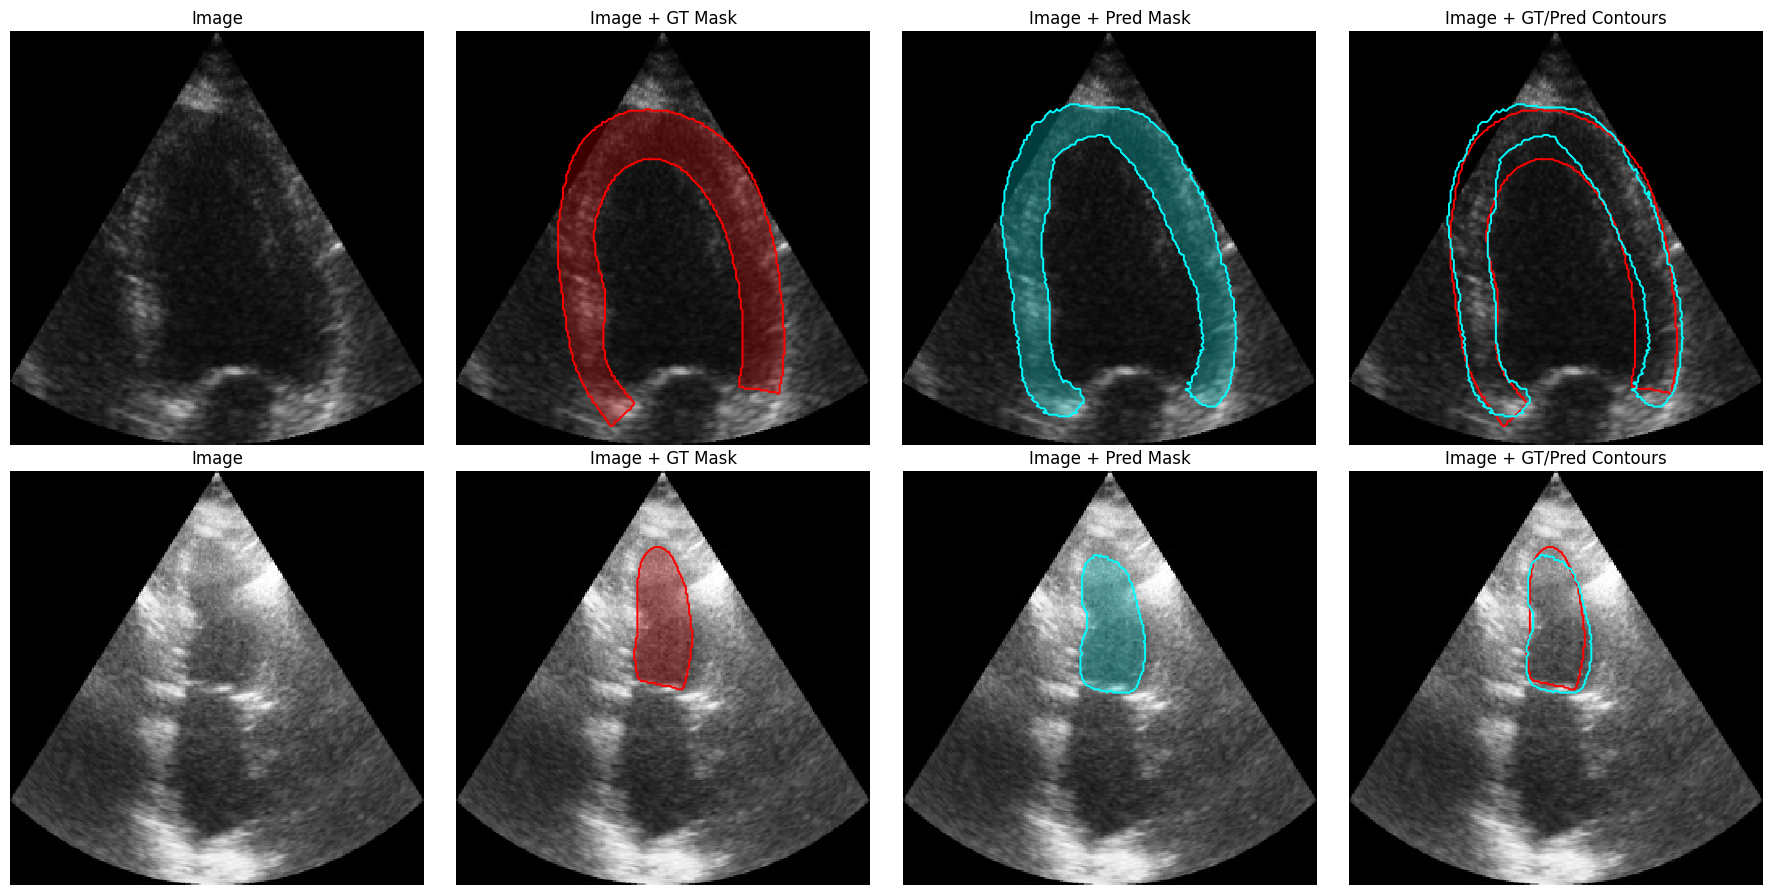

### CardiacUDA

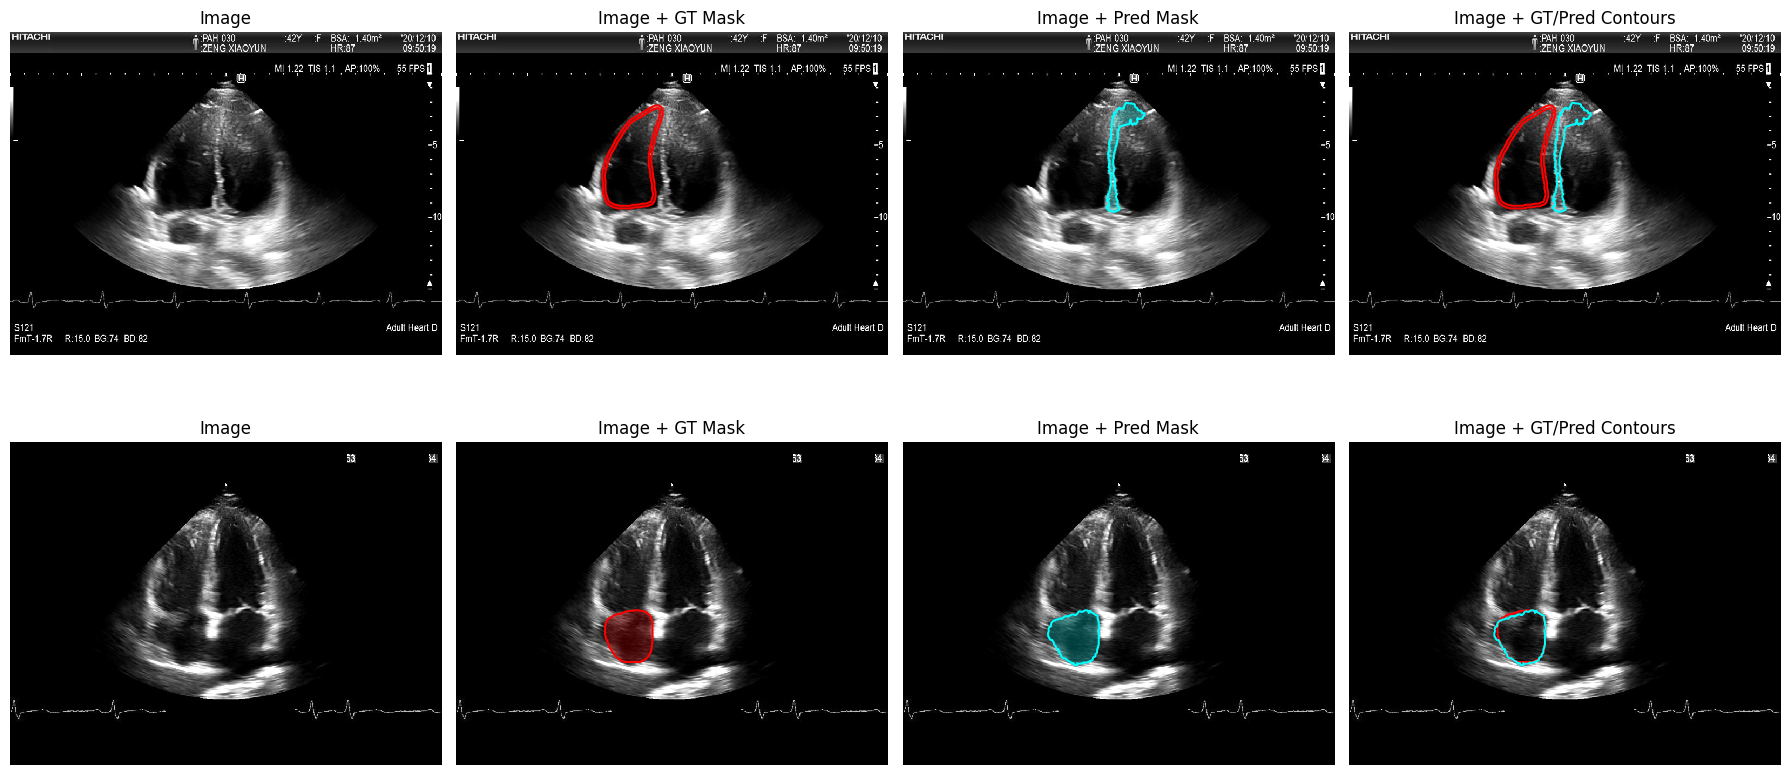

### EchoCP

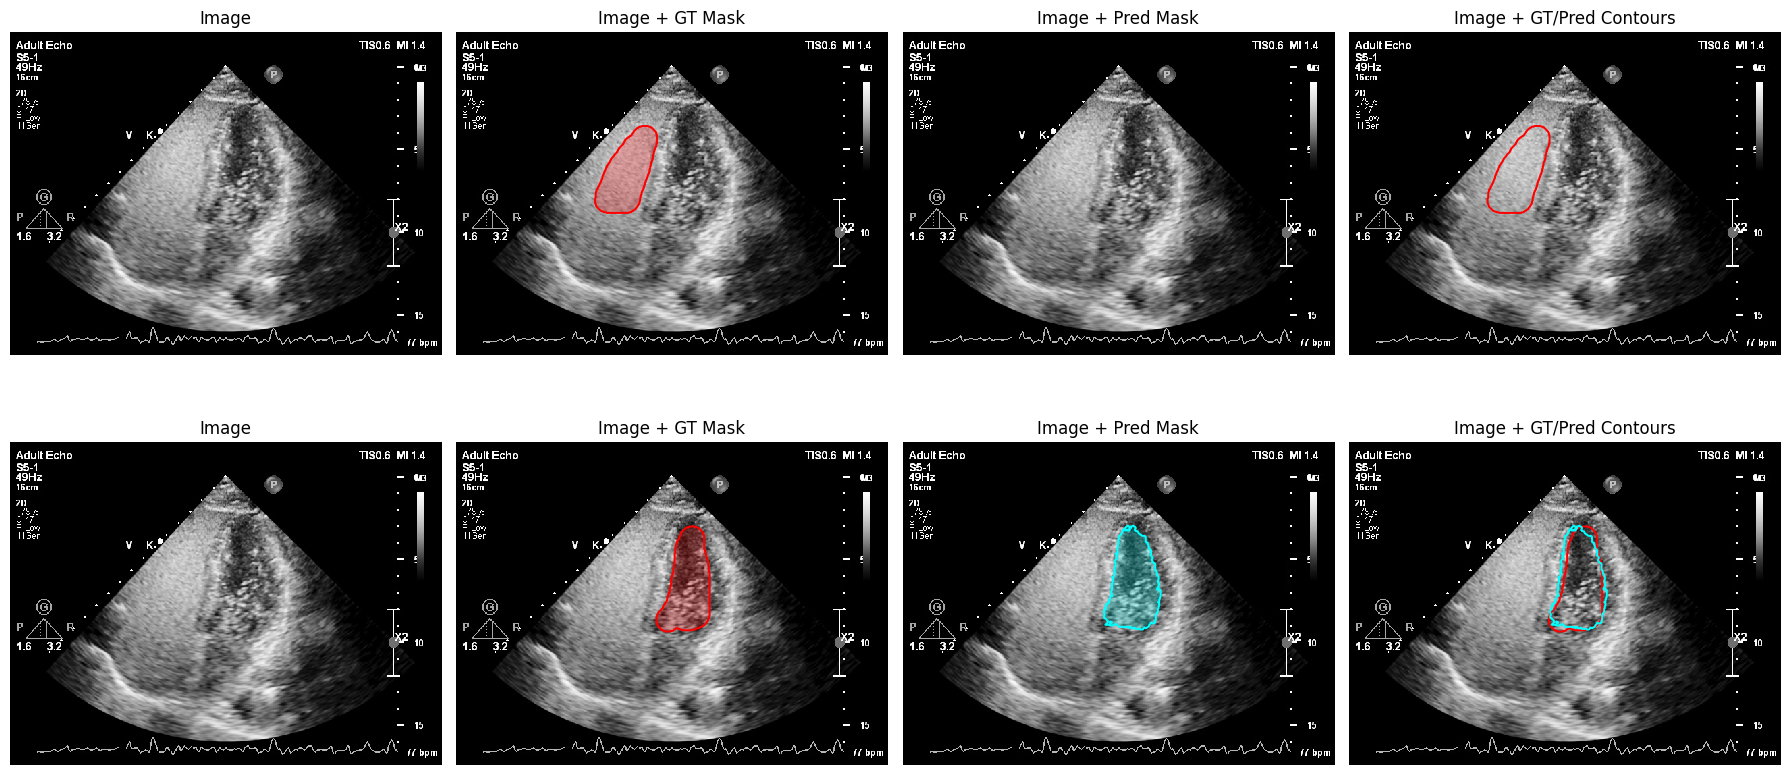

### SegRWMA

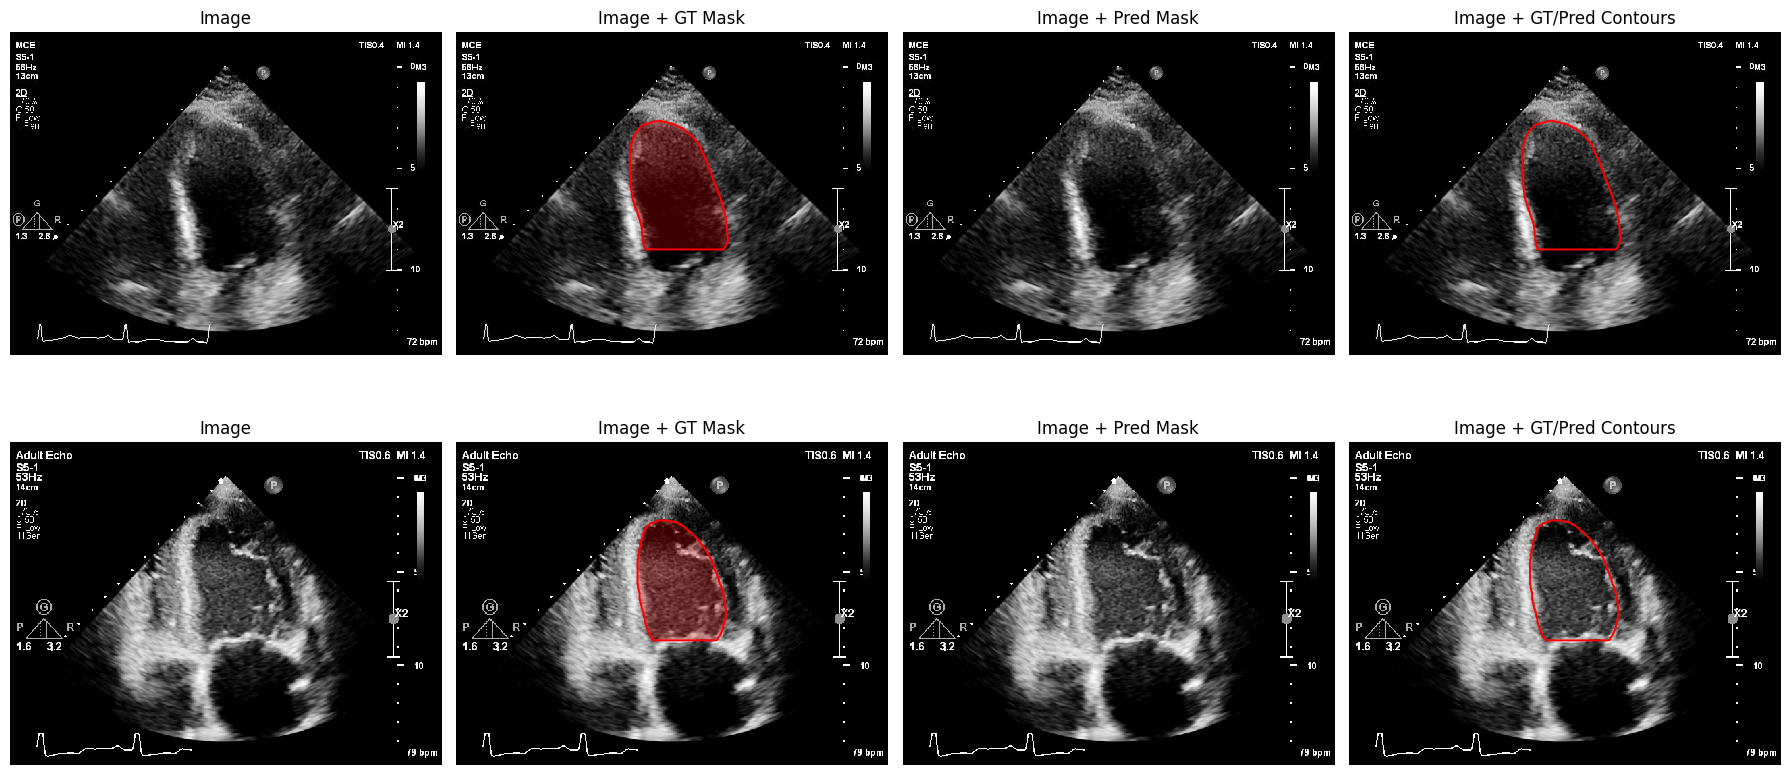

In [120]:
plot_qualitative_results(
    df,
    VALID_DIR,
    QUAL_DATA_ROOT,
    SPLIT,
    examples_per_dataset=QUAL_EXAMPLES_PER_DATASET,
    sort_metric=QUAL_SORT_METRIC,
    ascending=QUAL_SORT_ASCENDING,
    dataset_order=DATASET_ORDER,
    random_seed=QUAL_RANDOM_SEED,
)
